## **SUPERVISED LEARNING**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('train.csv')
df.head() # show the first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Check Missing and Duplicates Values**

In [9]:
missing_values = df.isnull().sum()
print("Missing values in each column: ")
print(missing_values)

Missing values in each column: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.drop('Cabin', axis=1, inplace=True) # Drop 'Cabin' column due to too many missing values 
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [15]:
missing_values = df.isnull().sum()
print("Missing values in each column: ")
print(missing_values)

Missing values in each column: 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
duplicate_values = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_values)

Number of duplicate rows: 0


## **Data cleaning and preprocessing**

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])  # Male=1, Female=0
df['Embarked'] = encoder.fit_transform(df['Embarked'])  

# Define features (X) and target (y)
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]  # Input variables
y = df['Survived']  # Target

# Scale the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

## **Visualization**

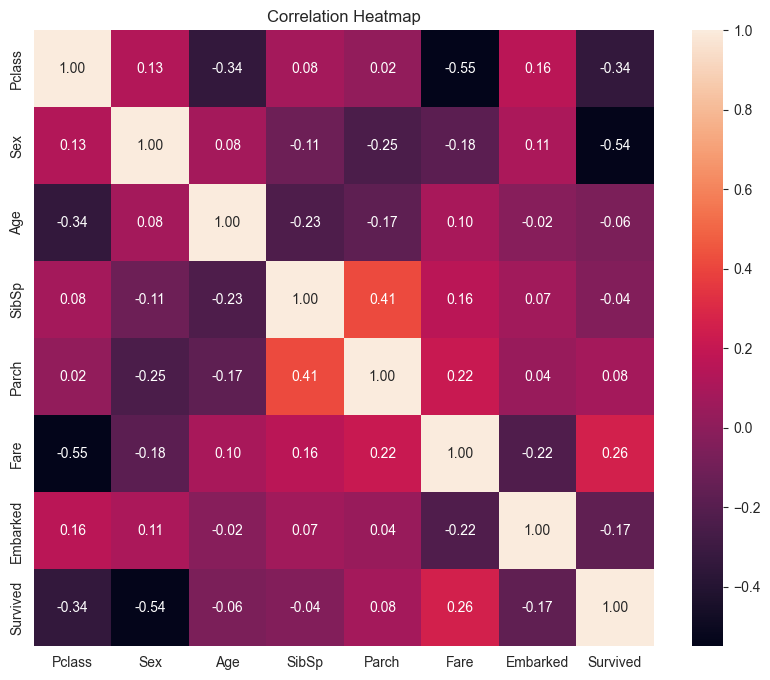

In [25]:
# Combine scaled features with target for visualization
df_viz = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_viz.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## **Machine Learning Model - KNN**

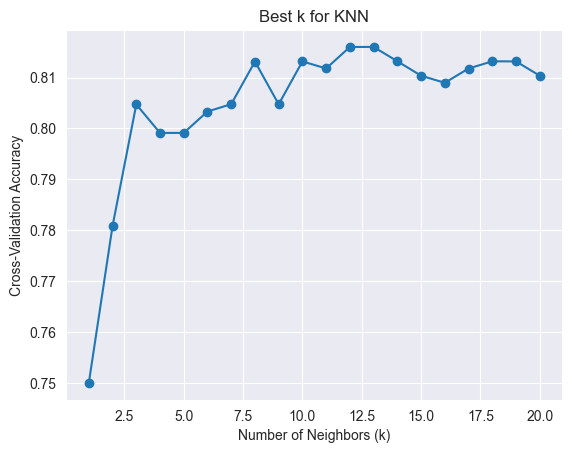

Best k: 13


In [27]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Find the best k using cross-validation
# Select the optimal number of neighbors for the KNN algorithm
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

plt.plot(k_values, cv_scores, marker='o')
plt.title("Best k for KNN")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.show()

best_k = k_values[cv_scores.index(max(cv_scores))]
print("Best k:", best_k)

In [28]:
# Train the model using the best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

y_pred = knn_best.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7988826815642458
Confusion Matrix:
 [[92 13]
 [23 51]]
